In [99]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

## read data

In [100]:
df = pd.read_csv('../data/processed/card_krueger_1994_long.csv')

In [101]:
df.columns

Index(['store_id', 'is_nj', 'is_post', 'chain', 'is_company_owned', 'region',
       'n_emp_fulltime', 'n_emp_parttime', 'n_managers', 'wage_start',
       'months_to_raise', 'first_raise', 'meals', 'open_hour', 'hrs_open',
       'price_soda', 'price_fry', 'price_entree', 'n_registers',
       'n_registers_11am', 'has_bonus', 'pct_affected', 'interview_type',
       'date', 'has_special_program', 'n_fte'],
      dtype='str')

In [102]:
## Model 1 — Basic DiD (no controls, no fixed effects)
formula_m1 = 'n_fte ~ is_nj + is_post + is_nj:is_post'
model_m1 = smf.ols(formula=formula_m1, data=df).fit()

terms = ['is_nj', 'is_post', 'is_nj:is_post']
print(f"{'':<20s}  {'coef':>8}  {'std err':>8}  {'t':>6}  {'p-value':>8}  {'[0.025':>8}  {'0.975]':>8}")
print('-' * 80)
ci = model_m1.conf_int()
for term in terms:
    coef = model_m1.params[term]
    se   = model_m1.bse[term]
    t    = model_m1.tvalues[term]
    p    = model_m1.pvalues[term]
    lo   = ci.loc[term, 0]
    hi   = ci.loc[term, 1]
    print(f"{term:<20s}  {coef:>8.3f}  {se:>8.3f}  {t:>6.2f}  {p:>8.3f}  {lo:>8.3f}  {hi:>8.3f}")
print(f"\nR-squared: {model_m1.rsquared:.3f}   N: {int(model_m1.nobs)}")

                          coef   std err       t   p-value    [0.025    0.975]
--------------------------------------------------------------------------------
is_nj                   -2.800     1.187   -2.36     0.019    -5.130    -0.469
is_post                 -1.951     1.505   -1.30     0.195    -4.905     1.004
is_nj:is_post            2.718     1.678    1.62     0.106    -0.576     6.012

R-squared: 0.007   N: 777


## Model 2 — Observable Store Characteristics

Adds chain, region, and company ownership as controls instead of store fixed effects.
These capture *observed* between-store differences. The gap between this R-squared and
Model 3's shows how much unobserved store heterogeneity remains.

In [103]:
formula_m2 = 'n_fte ~ is_nj + is_post + is_nj:is_post + C(chain) + C(region) + is_company_owned'
model_m2 = smf.ols(formula=formula_m2, data=df).fit()

terms = ['is_nj', 'is_post', 'is_nj:is_post', 'is_company_owned',
         'C(chain)[T.KFC]', 'C(chain)[T.Roy Rogers]', "C(chain)[T.Wendy's]",
         'C(region)[T.central_nj]', 'C(region)[T.north_nj]',
         'C(region)[T.pa_easton]', 'C(region)[T.pa_philly_suburbs]', 'C(region)[T.shore]']
terms = [t for t in terms if t in model_m2.params.index]

print(f"{'':<35s}  {'coef':>8}  {'std err':>8}  {'t':>6}  {'p-value':>8}  {'[0.025':>8}  {'0.975]':>8}")
print('-' * 80)
ci = model_m2.conf_int()
for term in terms:
    coef = model_m2.params[term]
    se   = model_m2.bse[term]
    t    = model_m2.tvalues[term]
    p    = model_m2.pvalues[term]
    lo   = ci.loc[term, 0]
    hi   = ci.loc[term, 1]
    print(f"{term:<35s}  {coef:>8.3f}  {se:>8.3f}  {t:>6.2f}  {p:>8.3f}  {lo:>8.3f}  {hi:>8.3f}")
print(f"\nR-squared: {model_m2.rsquared:.3f}   N: {int(model_m2.nobs)}")

                                         coef   std err       t   p-value    [0.025    0.975]
--------------------------------------------------------------------------------
is_nj                                   5.592     0.789    7.09     0.000     4.043     7.141
is_post                                -2.001     1.322   -1.51     0.130    -4.595     0.594
is_nj:is_post                           2.751     1.474    1.87     0.062    -0.142     5.644
is_company_owned                       -0.559     0.710   -0.79     0.431    -1.952     0.835
C(chain)[T.KFC]                       -10.460     0.827  -12.65     0.000   -12.083    -8.837
C(chain)[T.Roy Rogers]                 -1.660     0.849   -1.96     0.051    -3.327     0.006
C(chain)[T.Wendy's]                    -1.348     0.902   -1.49     0.136    -3.118     0.423
C(region)[T.north_nj]                  -0.049     0.887   -0.06     0.956    -1.790     1.692
C(region)[T.pa_easton]                  6.406     0.837    7.66     0.000

## Model 3 — Store Fixed Effects

Every store gets its own intercept, absorbing *all* time-invariant variation —
observed and unobserved. `is_nj` drops out (constant within each store, collinear
with store dummies). The DiD estimate `is_nj:is_post` is now identified purely from
within-store change over time.

In [104]:
df_m3 = df.dropna(subset=['n_fte'])

formula_m3 = 'n_fte ~ is_post + is_nj:is_post + C(store_id)'
model_m3 = smf.ols(formula=formula_m3, data=df_m3).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_m3['store_id']}
)

terms = ['is_post', 'is_nj:is_post']
print(f"{'':<20s}  {'coef':>8}  {'std err':>8}  {'t':>6}  {'p-value':>8}  {'[0.025':>8}  {'0.975]':>8}")
print('-' * 80)
ci = model_m3.conf_int()
for term in terms:
    coef = model_m3.params[term]
    se   = model_m3.bse[term]
    t    = model_m3.tvalues[term]
    p    = model_m3.pvalues[term]
    lo   = ci.loc[term, 0]
    hi   = ci.loc[term, 1]
    print(f"{term:<20s}  {coef:>8.3f}  {se:>8.3f}  {t:>6.2f}  {p:>8.3f}  {lo:>8.3f}  {hi:>8.3f}")
print(f"\nR-squared: {model_m3.rsquared:.3f}   N: {int(model_m3.nobs)}")

                          coef   std err       t   p-value    [0.025    0.975]
--------------------------------------------------------------------------------
is_post                 -2.076     1.772   -1.17     0.241    -5.550     1.397
is_nj:is_post            2.737     1.897    1.44     0.149    -0.981     6.455

R-squared: 0.778   N: 777


## Model Comparison

| | R-squared | DiD coef | Std Err | p-value |
|---|---|---|---|---|
| Model 1: No controls | | | | |
| Model 2: Observable characteristics | | | | |
| Model 3: Store fixed effects | | | | |

Fill in from the outputs above. The story to look for:
- **R² jump from M1 → M2**: how much chain/region/ownership explains employment variation
- **R² jump from M2 → M3**: unobserved store heterogeneity that observables miss
- **Std err shrinking M1 → M3**: why FEs improve precision of the DiD estimate

In [105]:
print(f"{'Model':<35s}  {'R-sq':>6}  {'DiD coef':>9}  {'Std Err':>8}  {'p-value':>8}  {'[0.025':>8}  {'0.975]':>8}")
print('-' * 93)
for label, model in [
    ('M1: No controls',                model_m1),
    ('M2: Observable characteristics', model_m2),
    ('M3: Store fixed effects',         model_m3),
]:
    term = 'is_nj:is_post'
    ci = model.conf_int()
    print(f"{label:<35s}  {model.rsquared:>6.3f}  {model.params[term]:>9.3f}"
          f"  {model.bse[term]:>8.3f}  {model.pvalues[term]:>8.3f}"
          f"  {ci.loc[term,0]:>8.3f}  {ci.loc[term,1]:>8.3f}")

Model                                  R-sq   DiD coef   Std Err   p-value    [0.025    0.975]
---------------------------------------------------------------------------------------------
M1: No controls                       0.007      2.718     1.678     0.106    -0.576     6.012
M2: Observable characteristics        0.242      2.751     1.474     0.062    -0.142     5.644
M3: Store fixed effects               0.778      2.737     1.897     0.149    -0.981     6.455


## assumption of parallel trends

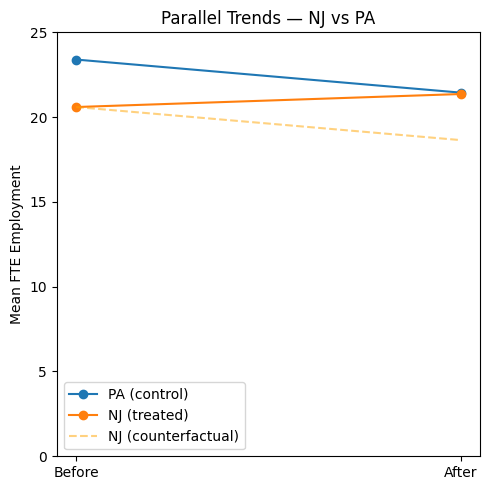

In [106]:
pivot_parallel_trends = pd.pivot_table(df, index='is_post', columns='is_nj', values='n_fte', aggfunc='mean')
pivot_parallel_trends.columns = ['PA (control)', 'NJ (treated)']
pivot_parallel_trends.index = ['Before', 'After']

pa_change = pivot_parallel_trends.loc['After', 'PA (control)'] - pivot_parallel_trends.loc['Before', 'PA (control)']
nj_counterfactual = [
    pivot_parallel_trends.loc['Before', 'NJ (treated)'],
    pivot_parallel_trends.loc['Before', 'NJ (treated)'] + pa_change,
]

x = [0, 1]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x, pivot_parallel_trends['PA (control)'].values, marker='o', label='PA (control)')
ax.plot(x, pivot_parallel_trends['NJ (treated)'].values, marker='o', label='NJ (treated)')
ax.plot(x, nj_counterfactual, linestyle='--', color='orange', alpha=0.5, label='NJ (counterfactual)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Before', 'After'])
ax.set_xlabel('')
ax.set_ylabel('Mean FTE Employment')
ax.set_title('Parallel Trends — NJ vs PA')
ax.set_ylim(0, 25)
ax.legend()
plt.tight_layout()
plt.show()

# placebo test

In [117]:
subset = df[df['is_nj'] == 0].copy() 
pa_stores = subset['store_id'].unique()
rng = np.random.default_rng(seed=42)
fake_treated = rng.choice(pa_stores, size=len(pa_stores)//2, replace=False)
subset['is_fake_treated'] = subset['store_id'].isin(fake_treated).astype(int)


subset_m3 = subset.dropna(subset=['n_fte'])



formula_m3 = 'n_fte ~ is_post + is_fake_treated + is_fake_treated:is_post + C(store_id)'
model_subset_m3 = smf.ols(formula=formula_m3, data=subset_m3).fit(
    cov_type='cluster',
    cov_kwds={'groups': subset_m3['store_id']}
)

terms = ['is_post', 'is_fake_treated:is_post']
print(f"{'':<20s}  {'coef':>8}  {'std err':>8}  {'t':>6}  {'p-value':>8}  {'[0.025':>8}  {'0.975]':>8}")
print('-' * 80)
ci = model_subset_m3.conf_int()
for term in terms:
    coef = model_subset_m3.params[term]
    se   = model_subset_m3.bse[term]
    t    = model_subset_m3.tvalues[term]
    p    = model_subset_m3.pvalues[term]
    lo   = ci.loc[term, 0]
    hi   = ci.loc[term, 1]
    print(f"{term:<20s}  {coef:>8.3f}  {se:>8.3f}  {t:>6.2f}  {p:>8.3f}  {lo:>8.3f}  {hi:>8.3f}")
print(f"\nR-squared: {model_subset_m3.rsquared:.3f}   N: {int(model_subset_m3.nobs)}")


                          coef   std err       t   p-value    [0.025    0.975]
--------------------------------------------------------------------------------
is_post                 -1.875     2.560   -0.73     0.464    -6.892     3.142
is_fake_treated:is_post    -0.389     3.646   -0.11     0.915    -7.535     6.758

R-squared: 0.728   N: 152


In [ ]:
# df_m3 = df.dropna(subset=['n_fte'])

# formula_m3 = 'n_fte ~ is_post + is_nj:is_post + C(store_id)'
# model_m3 = smf.ols(formula=formula_m3, data=df_m3).fit(
#     cov_type='cluster',
#     cov_kwds={'groups': df_m3['store_id']}
# )

# terms = ['is_post', 'is_nj:is_post']
# print(f"{'':<20s}  {'coef':>8}  {'std err':>8}  {'t':>6}  {'p-value':>8}  {'[0.025':>8}  {'0.975]':>8}")
# print('-' * 80)
# ci = model_m3.conf_int()
# for term in terms:
#     coef = model_m3.params[term]
#     se   = model_m3.bse[term]
#     t    = model_m3.tvalues[term]
#     p    = model_m3.pvalues[term]
#     lo   = ci.loc[term, 0]
#     hi   = ci.loc[term, 1]
#     print(f"{term:<20s}  {coef:>8.3f}  {se:>8.3f}  {t:>6.2f}  {p:>8.3f}  {lo:>8.3f}  {hi:>8.3f}")
# print(f"\nR-squared: {model_m3.rsquared:.3f}   N: {int(model_m3.nobs)}")